<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [35]:
#Importation de la librairie Pandas
import pandas as pd

In [36]:
#Importation de la librairie plotly express
import plotly.express as px

In [37]:
#Importation de la librairie numpy
import numpy as np

In [38]:
#Importation de la librairie seaborn
import seaborn as sns

In [39]:
#L'instruction permettant d'afficher toutes les colonnes d'un dataframe
pd.set_option('display.max_columns', None)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [40]:
#Utilisation de Google Drive pour stocker la data
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
#Importation du fichier web.xlsx
df_web = pd.read_excel('/content/drive/MyDrive/PROJET 6 Openclassrooms/web.xlsx')
#Importation du fichier erp.xlsx
df_erp = pd.read_excel('/content/drive/MyDrive/PROJET 6 Openclassrooms/erp.xlsx')
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel('/content/drive/MyDrive/PROJET 6 Openclassrooms/liaison.xlsx')

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [ ]:
#Afficher les 5 premières lignes de la table
df_erp.head()


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [ ]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
nb_doublons = df_erp["product_id"].duplicated().sum()
print("Nombre de doublons sur product_id :", nb_doublons)

Nombre de doublons sur product_id : 0


On n'a pas de doublons dans la colonne "**product_id**" ce qui veut dire qu'on peut utiliser ce dernier comme ***PREMIER KEY(PK)*** qui sécurise nos futures jointures:

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [ ]:
#Les prix non renseignés nuls
nb_prix_manquants = df_erp["price"].isna().sum()
print("Nombres d'articles avec un prix non renseigné: {}".format(nb_prix_manquants))


Nombres d'articles avec un prix non renseigné: 0


In [ ]:
#Le prix minimum
prix_min = df_erp["price"].min()
print("Prix minimum: {}".format(prix_min))


Prix minimum: -20.0


In [ ]:
#Le prix maximum
prix_max = df_erp["price"].max()
print("Prix maximum: {}".format(prix_max))


Prix maximum: 225.0


In [ ]:
# Les prix < 0
prix_negatifs = df_erp[df_erp["price"] < 0][["product_id", "price"]]
prix_negatifs


,product_id,price
151,4233,-20.0
469,5017,-8.0
739,6594,-9.1


Un prix négatif est impossible en vente > c’est une erreur de saisie **(surtout que les valeurs sont réalistes [-20.0; -8.0; -9.1])**.

Il faut corriger ces valeurs en supposant que le signe “-” est une erreur, donc on prend la valeur absolue.

Et on garde une liste des corrections “récap des corrections à mettre en place”.

On a **3 produits** qui ont **des prix négatifs**.

In [ ]:
#Sauvegarder les lignes concernées
prix_negatifs_avant = df_erp.loc[df_erp["price"] < 0, ["product_id", "price"]].copy()
prix_negatifs_avant



,product_id,price
151,4233,-20.0
469,5017,-8.0
739,6594,-9.1


In [ ]:
#Correction des prix négatifs
df_erp.loc[df_erp["price"] < 0, "price"] = df_erp.loc[df_erp["price"] < 0, "price"].abs()


In [ ]:
#Vérification qu'il n'y a plus des prix négatifs
df_erp[df_erp["price"] < 0][["product_id", "price"]]

,product_id,price


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [ ]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
df_erp["stock_status"].value_counts()


,count
stock_status,
instock,733
outofstock,92


**Stock_status** est lié directement à **Stock_quantity**
- stock_quantity > 0 <> stock_status devrait être instock

- stock_quantity = 0 <> stock_status devrait être outofstock

- stock_quantity < 0 <> erreur (stock négatif = erreur de saisie )

In [ ]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(
    lambda x: "outofstock" if x == 0 else "instock")



In [ ]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,0
0,True
1,True
2,True
3,True
4,False
...,...
820,True
821,True
822,True
823,True


In [ ]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
df_erp["coherence_stock"] = (df_erp["stock_status"] == df_erp["stock_status_2"])
df_erp["coherence_stock"].sum()


np.int64(821)

In [ ]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
df_erp[df_erp["coherence_stock"] == False][
    ["product_id", "stock_quantity", "stock_status", "stock_status_2"]
]


,product_id,stock_quantity,stock_status,stock_status_2
4,4039,3,outofstock,instock
398,4885,0,instock,outofstock
449,4973,-10,outofstock,instock
573,5700,-1,outofstock,instock


4039 : stock_quantity = 3 mais stock_status = outofstock > devrait être instock

4885 : stock_quantity = 0 mais stock_status = instock > devrait être outofstock

4973 : stock_quantity = -10 > stock négatif (anormal)

5700 : stock_quantity = -1 > stock négatif (anormal)
** Suggestion : nouvel inventaire pour mieux verifier les stocks négatifs, il faut savoir d'où cela vient soit un erreur de saisie ou autres raisons (approvisionnement, annulation, retour, conditionnement...)**

In [ ]:
# Corriger les stocks négatifs : on les met à 0
df_erp.loc[df_erp["stock_quantity"] < 0, "stock_quantity"] = 0


In [ ]:
# Mettre stock_status cohérent avec la quantité
df_erp.loc[df_erp["stock_quantity"] == 0, "stock_status"] = "outofstock"
df_erp.loc[df_erp["stock_quantity"] > 0, "stock_status"] = "instock"


In [ ]:
# Recréer stock_status_2 (statut théorique à partir du stock)
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(
    lambda x: "outofstock" if x == 0 else "instock"
)

# Comparaison : True si cohérent, False sinon
df_erp["coherence_stock"] = (df_erp["stock_status"] == df_erp["stock_status_2"])

# Synthèse
print("Lignes cohérentes :", df_erp["coherence_stock"].sum(), "/", df_erp.shape[0])


Lignes cohérentes : 825 / 825


In [ ]:
stock_min = df_erp["stock_quantity"].min()
print("Stock minimum:", stock_min)


Stock minimum: 0


In [ ]:
stock_max = df_erp["stock_quantity"].max()
print("Stock maximum:", stock_max)


Stock maximum: 145


In [ ]:
stocks_negatifs = df_erp[df_erp["stock_quantity"] < 0][["product_id", "stock_quantity"]]
stocks_negatifs


,product_id,stock_quantity


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [ ]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient.
df_erp["onsale_web"].value_counts()



,count
onsale_web,
1,716
0,109


1 = produit vendu en ligne / visible sur le site

0 = produit non vendu en ligne / non visible sur le site

In [ ]:
#Colonnes importantes pour l'analyse de la data

#product_id : identifiant produit ERP (PK)
#price : prix de vente (utile pour CA)
#stock_quantity : stock (rotation, mois de stock)
#stock_status : statut stock (info catégorielle)
#onsale_web : vendu sur le web ou non (filtre important)


In [ ]:
#Supprimer la colonne comportant les libellés "coherence_stock" car colonne de contrôle et  "stock_status_2" car cette derniere est redondante
#avec la colonne "stock_status".
df_erp = df_erp.drop(columns=["stock_status_2", "coherence_stock"])




<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [ ]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"

#Afficher le prix minimum de la colonne "purchase_price"

#Afficher le prix maximum de la colonne "purchase_price"


In [ ]:
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
nb_pa_manquants = df_erp["purchase_price"].isna().sum()
print("Nombre d'articles avec un prix d'achat non renseigné: {}".format(nb_pa_manquants))


Nombre d'articles avec un prix d'achat non renseigné: 0


In [ ]:
#Afficher le prix minimum de la colonne "purchase_price"
pa_min = df_erp["purchase_price"].min()
print("Prix d'achat minimum: {}".format(pa_min))


Prix d'achat minimum: 2.74


In [ ]:
#Afficher le prix maximum de la colonne "purchase_price"
pa_max = df_erp["purchase_price"].max()
print("Prix d'achat maximum: {}".format(pa_max))

Prix d'achat maximum: 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [ ]:
#Dimension du dataset
#Nombre d'observations

#Nombre de caractéristiques
print("Nombre d'observations :", df_web.shape[0])
print("Nombre de caractéristiques :", df_web.shape[1])



Nombre d'observations : 1513
Nombre de caractéristiques : 29


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [ ]:
#Colonnes importantes pour l'analyse de la data
#"sku", "total_sales","tax_status", "post_type", "product_type"

In [ ]:
#Créer un nouveau dataframe df_web avec uniquement les colonnes importantes pour l'analyse de la data
colonnes_a_garder = ["sku", "total_sales","tax_status", "post_type", "product_type"]
df_web = df_web[colonnes_a_garder]
df_web.head()



NameError: name 'df_web' is not defined

In [ ]:
#Affichage des valeurs unique sku
valeurs_sku = df_web['sku'].unique()
print(valeurs_sku)

[11862 16057 14692 16295 15328 15471 16515 16246 nan 13572 16513 16585
 16269 15526 12869 15575 11586 14338 15425 16560 15361 13809 11587 15022
 14323 16342 16029 15475 13754 14680 15875 9636 13849 13662 16564 13557
 15429 14712 15032 15481 15448 16580 15441 804 15300 13958 16071 15678
 13895 15711 12882 16053 13766 16247 12640 15292 15476 15670 16189 16038
 14864 16044 15324 15531 15953 15413 15733 14366 15895 15892 16472 15185
 16010 15793 15849 12315 15741 15934 15148 15781 15659 15106 15490 14507
 14149 16307 13736 14090 16037 15758 14661 12587 15337 15489 15201 16305
 16131 13435 15747 12203 14509 14768 16262 14561 16505 15717 16129 13460
 15871 15940 11602 13127 13520 15480 13032 15436 15269 15910 19821 16263
 15138 15146 15126 15482 16186 13905 16540 15856 15677 14700 15325 19815
 3506 16056 14975 15341 15204 15415 16065 15479 16151 15127 15140 15779
 15473 15530 14805 14106 9937 15281 16553 15315 15668 13211 15161 11258
 16296 12588 15792 15921 15690 15775 15577 15870 802 15163

In [ ]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
sku_non_numeriques = df_web[df_web["sku"].notna() & (~df_web["sku"].astype(str).str.fullmatch(r"\d+"))]["sku"].unique()
sku_non_numeriques

array(['13127-1', 'bon-cadeau-25-euros'], dtype=object)

In [ ]:
#Identifier les lignes sans code article
df_web[df_web["sku"].isna()]

,sku,total_sales,tax_status,post_type,product_type
8,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
df_web[df_web["sku"].isin(sku_non_numeriques)]

,sku,total_sales,tax_status,post_type,product_type
272,13127-1,4.0,taxable,product,Vin
842,bon-cadeau-25-euros,7.0,NaN,attachment,Autre
1117,13127-1,4.0,NaN,attachment,Vin
1387,bon-cadeau-25-euros,7.0,taxable,product,NaN


In [ ]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
nb_doublons_sku = df_web["sku"].dropna().duplicated().sum()
print("Nombre de doublons sur sku :", nb_doublons_sku)

Nombre de doublons sur sku : 714


In [ ]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, il faut que je réalise les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_web_sans_sku = df_web[df_web["sku"].isna()]
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_web_sans_sku.info()

NameError: name 'df_web' is not defined

Les SKU non numériques : ce ne sont pas forcément des erreurs (variante / bon cadeau), mais il faut éviter le double comptage en gardant seulement **post_type="product**".

Le nombre élevé de **doublons (714)** s’explique par la présence de **lignes attachment**.

**Les lignes sans SKU** (85) sont quasi toutes vides (83) > **à supprimer**.

In [ ]:
#Suppression des lignes sans Sku
df_web = df_web[df_web["sku"].notna()]
#Garder uniquement les lignes "produits" et retirer "attachment"
df_web = df_web[df_web["post_type"] == "product"]
#Vérification suppression doublons
nb_doublons_sku = df_web["sku"].duplicated().sum()
print("Nombre de doublons sur sku après nettoyage :", nb_doublons_sku)

Nombre de doublons sur sku après nettoyage : 0


In [ ]:
#Nouvelles dimensions après nettoyage :
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))

Le tableau comporte 714 observation(s) ou article(s)
Le tableau comporte 5 colonne(s)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [ ]:
#Dimension du dataset
#Nombre d'observations
print("Nombre d'observations :", df_liaison.shape[0])
#Nombre de caractéristiques
print("Nombre de caractéristiques :", df_liaison.shape[1])

Nombre d'observations : 825
Nombre de caractéristiques : 2


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [ ]:
#L'unicité des valeurs dans la colonne "product_id" est importante 
# car elle est utilisée comme clé primaire pour identifier de manière unique chaque produit dans le dataset. 
nb_doublons_product_id = df_liaison["product_id"].duplicated().sum()
print("Nombre de doublons sur product_id :", nb_doublons_product_id)

Nombre de doublons sur product_id : 0


In [ ]:
#Unicité de la colonne "id_web" : clé primaire
nb_doublons_id_web = df_liaison['id_web'].duplicated().sum()
print("Nombre de doublons sur id_web :", nb_doublons_id_web)
df_liaison[df_liaison["id_web"].duplicated(keep=False)].sort_values("id_web")

Nombre de doublons sur id_web : 90


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


In [ ]:
#Vérification des articles sans correspondance
nb_doublons_id_web = df_liaison["id_web"].dropna().duplicated().sum()
print("Nombre de doublons sur id_web (hors NaN) :", nb_doublons_id_web)
print("Articles sans correspondance (id_web manquant) :", df_liaison["id_web"].isna().sum())

Nombre de doublons sur id_web (hors NaN) : 0
Articles sans correspondance (id_web manquant) : 91


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [ ]:
#Fusion des fichiers df_erp et df_liaison
df_merge = df_erp.merge(df_liaison, on="product_id", how="left")
print("ERP :", df_erp.shape)
print("LIAISON :", df_liaison.shape)
print("MERGE :", df_merge.shape)

ERP : (825, 6)
LIAISON : (825, 2)
MERGE : (825, 7)


In [ ]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
nb_non_match = df_merge["id_web"].isna().sum()
print("Nombre de lignes ERP sans correspondance Web (id_web manquant) :", nb_non_match)

Nombre de lignes ERP sans correspondance Web (id_web manquant) : 91


In [ ]:
#Affichage lignes sans correspondance web
df_merge[df_merge["id_web"].isna()][["product_id"]]

,product_id
19,4055
49,4090
50,4092
119,4195
131,4209
...,...
817,7196
818,7200
819,7201
820,7203


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [ ]:
#Fusionner les datasets df_merge et df_web
df_merge_web = df_merge.merge(df_web, left_on="id_web", right_on="sku", how="left")

In [ ]:
#Avons-nous des lignes sans correspondance?
nb_sans_correspondance_web = df_merge_web["sku"].isna().sum()
print("Nombre de lignes sans correspondance avec le fichier web :", nb_sans_correspondance_web)

Nombre de lignes sans correspondance avec le fichier web : 111


In [ ]:
#Les lignes sans correspondance
df_merge_web[df_merge_web["sku"].isna()][["product_id", "id_web"]]

,product_id,id_web
19,4055,NaN
49,4090,NaN
50,4092,NaN
119,4195,NaN
131,4209,NaN
...,...,...
818,7200,NaN
819,7201,NaN
820,7203,NaN
821,7204,NaN


***91*** = produits ERP sans identifiant web

***20*** = identifiants web présents dans la liaison, mais absents (ou format différent) dans df_web

In [ ]:
#Séparation des 2 causes
#Les lignes sans correspondance parce que id_web est manquant
df_merge_web[df_merge_web["id_web"].isna()][["product_id", "id_web"]].shape

(91, 2)

In [ ]:
#Les lignes sans correspondance alors que id_web est renseigné
df_merge_web[df_merge_web["id_web"].notna() & df_merge_web["sku"].isna()][["product_id", "id_web"]]

,product_id,id_web
193,4289,13771
236,4568,15065
241,4584,14785
355,4741,12601
391,4864,15154
394,4869,14360
424,4921,15608
425,4922,15586
470,5018,15272
473,5021,15630


In [ ]:
#Afficher id_web renseigné mais avec problème
ids_web_probleme = df_merge_web[df_merge_web["id_web"].notna() & df_merge_web["sku"].isna()]["id_web"].unique()
print (ids_web_probleme)
df_web[df_web["sku"].isin(ids_web_probleme)]["sku"].unique()
#Aucun des 20 id_web problématiques n’existe dans df_web["sku"]

[13771 15065 14785 12601 15154 14360 15608 15586 15272 15630 14648 14715
 14730 14689 14379 15609 14377 13577 15529 '14680-1']


array([], dtype=object)

Après jointure, **111 lignes** n’ont pas de correspondance web. **91** proviennent de id_web manquant dans la liaison. Les **20** restantes ont un id_web renseigné mais absent du fichier web (aucune correspondance dans les SKU), ce qui indique un problème de mise à jour de la table de liaison ou un export web incomplet.

In [ ]:
#Ici pour que je puisse être sur de ne pas avoir des fausses résultats dans mes prochaines analyses
#je décide de créer 2 tables :
#Table CA / ventes web : je garde uniquement les lignes qui ont une correspondance web (sku non nul). Comme ça, je peux calculer le CA sans avoir des trous.
#Table stock ERP : je garde tout l’ERP (même sans web) pour analyser stock, rotation...
df_merge_web = df_merge_web.copy()
df_merge_web_supp = df_merge_web[df_merge_web["sku"].notna()].copy()
print("df_merge_web :", df_merge_web.shape)
print("df_merge_web_supp :", df_merge_web_supp.shape)

df_merge_web : (825, 12)
df_merge_web_supp : (714, 12)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

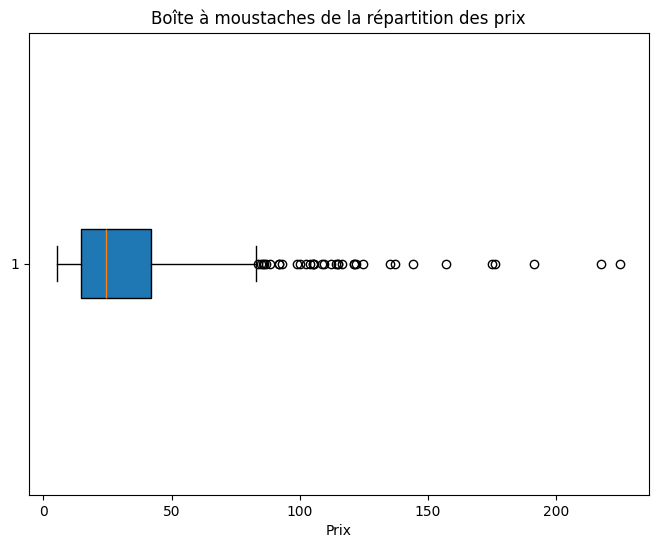

In [ ]:
# Création d'une boîte à moustache de la répartition des prix grâce à Pandas
import matplotlib.pyplot as plt

price_data = df_merge_web['price']

# Créer une boîte à moustaches
plt.figure(figsize=(8, 6))
plt.boxplot(price_data, vert=False, patch_artist=True)

# Ajouter des titres et des labels
plt.title('Boîte à moustaches de la répartition des prix')
plt.xlabel('Prix')

# Afficher le graphique
plt.show()

In [ ]:
#Autre méthode avec plotly express
fig = px.box(df_merge_web, x="price", title="Boîte à moustaches de la répartition des prix")
fig.show()

NameError: name 'df_merge_web' is not defined

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [ ]:
#Calculer la moyenne du prix
moyenne_prix = df_merge_web["price"].mean()
print("Moyenne du prix :", moyenne_prix)
#Calculer l'écart-type du prix
ecart_type_prix = df_merge_web["price"].std()
print("Écart-type du prix :", ecart_type_prix)
#Calculer le Z-score
df_merge_web["z_score_price"] = (df_merge_web["price"] - moyenne_prix) / ecart_type_prix
df_merge_web[["product_id", "price", "z_score_price"]]

Moyenne du prix : 32.27763636363637
Écart-type du prix : 26.603195978591984


,product_id,price,z_score_price
0,3847,24.2,-0.303634
1,3849,34.3,0.076020
2,3850,20.8,-0.431438
3,4032,14.1,-0.683288
4,4039,46.0,0.515816
...,...,...,...
820,7203,45.0,0.478227
821,7204,45.0,0.478227
822,7247,54.8,0.846604
823,7329,26.5,-0.217178


In [ ]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
seuil_prix_z3 = moyenne_prix + 3 * ecart_type_prix
print("Seuil de prix pour z-score > 3 :", seuil_prix_z3)

Seuil de prix pour z-score > 3 : 112.08722429941233


In [ ]:
#Afficher les lignes dont le prix est supérieur au seuil de prix pour z-score > 3
df_merge_web[df_merge_web["price"] > seuil_prix_z3].sort_values("price", ascending=False)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,post_type,product_type,z_score_price
208,4352,1,225.0,0,outofstock,137.81,15940,15940,11.0,taxable,product,Champagne,7.244331
460,5001,1,217.5,18,instock,116.87,14581,14581,2.0,taxable,product,Vin,6.962410
635,5892,1,191.3,98,instock,116.06,14983,14983,6.0,taxable,product,Champagne,5.977566
227,4402,1,176.0,11,instock,78.25,3510,3510,3.0,taxable,product,Cognac,5.402447
598,5767,1,175.0,12,instock,90.42,15185,15185,4.0,taxable,product,Vin,5.364858
230,4406,1,157.0,12,instock,69.08,7819,7819,4.0,taxable,product,Cognac,4.688247
242,4594,1,144.0,0,outofstock,87.36,NaN,NaN,NaN,NaN,NaN,NaN,4.199584
411,4904,1,137.0,9,instock,67.95,14220,14220,3.0,taxable,product,Vin,3.936458
697,6126,1,135.0,138,instock,80.33,14923,14923,5.0,taxable,product,Champagne,3.861279
556,5612,1,124.8,19,instock,66.41,14915,14915,1.0,taxable,product,Vin,3.477866


In [ ]:
# Tri pour que le graphique soit plus lisible (du moins cher au plus cher)
import plotly.graph_objects as go

tmp = df_merge_web.sort_values("price").reset_index(drop=True)
tmp["outlier_z3"] = tmp["z_score_price"] > 3

fig = px.scatter(
    tmp,
    x=tmp.index,
    y="price",
    color="outlier_z3",
    title="Prix triés — Seuil Z-score > 3",
    labels={"x": "Produits (index trié)", "price": "Prix (€)", "outlier_z3": "Outlier (z>3)"}
)

# Ligne seuil
fig.add_hline(y=seuil_prix_z3, line_dash="dash", annotation_text="Seuil z>3", annotation_position="top left")

fig.show()

D'après l'analyse du tableau, le Z-score (>3) identifie **17 produits** dont le prix est **supérieur à 112 €**. Les prix vont de **114 €** à **225 €**. Les catégories (Champagne, Cognac, Vin premium) et la cohérence avec le prix d’achat plus la présence de ventes suggèrent qu’il s’agit majoritairement de ***produits haut de gamme, pas d’erreurs***.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [ ]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge_web["price"].describe()

,price
count,825.000000
mean,32.277636
std,26.603196
min,5.200000
25%,14.500000
50%,24.300000
75%,42.000000
max,225.000000


In [ ]:
#Définir un seuil pour les articles "outliers" en prix
Q1 = df_merge_web["price"].quantile(0.25)
Q3 = df_merge_web["price"].quantile(0.75)
IQR = Q3 - Q1

borne_sup = Q3 + 1.5 * IQR
borne_inf = Q1 - 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Borne inf :", borne_inf)
print("Borne sup :", borne_sup)

Q1 : 14.5
Q3 : 42.0
IQR : 27.5
Borne inf : -26.75
Borne sup : 83.25


In [ ]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers_iqr = df_merge_web[df_merge_web["price"] > borne_sup]
nb_outliers = outliers_iqr.shape[0]
proportion_outliers = nb_outliers / df_merge_web.shape[0] * 100

print("Nombre d'articles outliers (IQR) :", nb_outliers)
print("Proportion d'outliers (%) :", proportion_outliers)

Nombre d'articles outliers (IQR) : 36
Proportion d'outliers (%) : 4.363636363636364


In [ ]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
outliers_iqr[["product_id", "price", "purchase_price", "total_sales", "product_type"]].sort_values("price", ascending=False)

,product_id,price,purchase_price,total_sales,product_type
208,4352,225.0,137.81,11.0,Champagne
460,5001,217.5,116.87,2.0,Vin
635,5892,191.3,116.06,6.0,Champagne
227,4402,176.0,78.25,3.0,Cognac
598,5767,175.0,90.42,4.0,Vin
230,4406,157.0,69.08,4.0,Cognac
242,4594,144.0,87.36,NaN,NaN
411,4904,137.0,67.95,3.0,Vin
697,6126,135.0,80.33,5.0,Champagne
556,5612,124.8,66.41,1.0,Vin


In [ ]:
fig = px.box(
    df_merge_web,
    y="price",
    title="Boxplot des prix — Méthode IQR",
    labels={"price": "Prix (€)"}
)

fig.add_hline(y=borne_sup, line_dash="dash", annotation_text="Borne sup IQR", annotation_position="top left")
fig.show()

Les outliers IQR semblent majoritairement **justifiés** : ils correspondent à ***des produits haut de gamme***, avec *un prix d’achat cohérent* et *des ventes observées*

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [ ]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge_web_supp["ca_par_article"] = df_merge_web_supp["price"] * df_merge_web_supp["total_sales"]
#Calculer la somme de la colonne "ca_par_article"
ca_total = df_merge_web_supp["ca_par_article"].sum().round(2)
#Ce résultat correspond au chiffre d'affaire du site web
print("Chiffre d'affaires total du site web :", ca_total,"€")

Chiffre d'affaires total du site web : 143680.1 €


In [ ]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_ca_sorted = df_merge_web_supp.sort_values("ca_par_article", ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_ca_sorted = df_ca_sorted.reset_index(drop=True)
#Afficher les 20 premiers articles en CA
top20_ca = df_ca_sorted.head(20)
top20_ca[["product_id", "id_web","product_type", "price", "total_sales", "ca_par_article"]]


,product_id,id_web,product_type,price,total_sales,ca_par_article
0,4352,15940,Champagne,225.0,11.0,2475.0
1,5892,14983,Champagne,191.3,6.0,1147.8
2,4353,12587,Champagne,79.5,14.0,1113.0
3,5826,15325,Vin,41.2,20.0,824.0
4,6212,13996,Vin,115.0,7.0,805.0
5,5026,13913,Champagne,86.8,9.0,781.2
6,5008,11602,Vin,105.0,7.0,735.0
7,5767,15185,Vin,175.0,4.0,700.0
8,6126,14923,Champagne,135.0,5.0,675.0
9,5025,13914,Champagne,112.0,6.0,672.0


In [ ]:
#Graphique en barre des 20 premiers articles avec plotly express
top20_ca = df_merge_web_supp.sort_values("ca_par_article", ascending=False).head(20).copy()
top20_ca["product_id_str"] = top20_ca["product_id"].astype(str)

fig = px.bar(
    top20_ca,
    x="product_id_str",
    y="ca_par_article",
    color="product_type",
    title="Top 20 articles par chiffre d'affaires",
    labels={"product_id_str": "Product ID", "ca_par_article": "CA (€)", "product_type": "Type produit"},
    hover_data=["product_type", "price", "total_sales"]
)

fig.update_layout(xaxis_tickangle=-45)
fig.update_traces(texttemplate="%{y:.0f} €", textposition="outside")
fig.update_layout(yaxis_range=[0, top20_ca["ca_par_article"].max() * 1.1])

fig.update_xaxes(categoryorder="array", categoryarray=top20_ca["product_id_str"].tolist())

fig.show()

In [ ]:
#############################
# Calculer le 20 / 80 en CA #
#############################
#Trier par CA décroissant
df_pareto = df_merge_web_supp.sort_values("ca_par_article", ascending=False).reset_index(drop=True)
#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_pareto["part_ca"] = df_pareto["ca_par_article"] / ca_total
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_pareto["part_ca_cumulee"] = df_pareto["part_ca"].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_articles_80 = (df_pareto["part_ca_cumulee"] <= 0.80).sum()
print("Nombre d'articles représentant ~80% du CA :", nb_articles_80)
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_articles_80 = round(nb_articles_80 / df_pareto.shape[0] * 100, 2)
print("Proportion d'articles correspondant à 80% du CA (%):", proportion_articles_80,"%")

Nombre d'articles représentant ~80% du CA : 434
Proportion d'articles correspondant à 80% du CA (%): 60.78 %


Environ **80% du chiffre d’affaires** est généré par **434 références**, soit **60,78% du catalogue web**. Le CA est donc réparti sur un grand nombre de produits, et ***ne suit pas un schéma 80/20 très concentré***.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [ ]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_qte_sorted = df_merge_web_supp.sort_values("total_sales", ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_qte_sorted = df_qte_sorted.reset_index(drop=True)
#Afficher les 20 premiers articles en quantité
top20_qte = df_qte_sorted.head(20)
top20_qte[["product_id", "id_web", "total_sales", "price", "ca_par_article", "product_type"]]
#Graphique en barre des 20 premiers articles avec plotly express
top20_qte = top20_qte.copy()
top20_qte["product_id_str"] = top20_qte["product_id"].astype(str)

fig = px.bar(
    top20_qte,
    x="product_id_str",
    y="total_sales",
    color="product_type",
    title="Top 20 articles par quantités vendues",
    labels={
        "product_id_str": "Product ID",
        "total_sales": "Quantités vendues",
        "product_type": "Type produit"
    },
    hover_data=["product_type", "price", "ca_par_article"]
)

fig.update_layout(xaxis_tickangle=-45)
fig.update_traces(texttemplate="%{y:.0f}", textposition="outside")
fig.update_layout(yaxis_range=[0, top20_qte["total_sales"].max() * 1.1])
fig.update_xaxes(categoryorder="array", categoryarray=top20_qte["product_id_str"].tolist())

fig.show()

In [ ]:
#############################
# Calculer le 20 / 80 en CA #
#############################
#Trier par quantités vendues décroissant
df_pareto_qte = df_merge_web_supp.sort_values("total_sales", ascending=False).reset_index(drop=True)
#Créer une colonne calculant la part en quantité de la ligne dans le dataset
qte_total = df_pareto_qte["total_sales"].sum()
df_pareto_qte["part_qte"] = df_pareto_qte["total_sales"] / qte_total
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_pareto_qte["part_qte_cumule"] = df_pareto_qte["part_qte"].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_articles_80_qte = (df_pareto_qte["part_qte_cumule"] <= 0.80).sum()
print("Nombre d'articles représentant ~80% des ventes (quantité) :", nb_articles_80_qte)
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_articles_80_qte = round(nb_articles_80_qte / df_pareto_qte.shape[0] * 100, 2)
print("Proportion d'articles correspondant à 80% des ventes (quantité) (%) :", proportion_articles_80_qte, "%")

Nombre d'articles représentant ~80% des ventes (quantité) : 433
Proportion d'articles correspondant à 80% des ventes (quantité) (%) : 60.64 %


**80% des quantités vendues** proviennent de **433 références (60,64% du catalogue)**. C’est **très proche** du résultat en **chiffre d’affaires (434 références, 60,78%)**. Cela montre que les ventes et le CA sont répartis sur un grand nombre de produits : notre activité **n’est pas dépendante** d’un petit groupe de ***best-sellers***.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [ ]:
######################################
# Calculer le nombre de mois de stock #
######################################
#Création de la colonne Rotation de stock
df_merge_web["mois_de_stock"] = df_merge_web["stock_quantity"] / df_merge_web["total_sales"]
#Remplacement des "inf" par 0
df_merge_web["mois_de_stock"] = df_merge_web["mois_de_stock"].replace([np.inf, -np.inf], 0)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_stock_sorted = df_merge_web.sort_values("mois_de_stock", ascending=False).reset_index(drop=True)
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
flop20_stock = df_stock_sorted.head(20).copy()
flop20_stock["product_id_str"] = flop20_stock["product_id"].astype(str)
flop20_stock["product_type_clean"] = flop20_stock["product_type"].fillna("Inconnu").astype(str)
fig = px.bar(
    flop20_stock,
    x="product_id_str",
    y="mois_de_stock",
    color="product_type_clean",
    title="Flop 20 — Produits avec le plus de mois de stock",
    labels={
        "product_id_str": "Product ID",
        "mois_de_stock": "Mois de stock",
        "product_type_clean": "Type produit"
    },
    hover_data=["product_type_clean", "stock_quantity", "total_sales"]
)
fig.update_layout(xaxis_tickangle=-45)
fig.update_traces(texttemplate="%{y:.1f}", textposition="outside")
fig.update_layout(yaxis_range=[0, flop20_stock["mois_de_stock"].max() * 1.1])
fig.update_xaxes(categoryorder="array", categoryarray=flop20_stock["product_id_str"].tolist())
fig.show()

In [ ]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge_web["Valorisation_stock_euros"] = df_merge_web["stock_quantity"] * df_merge_web["price"]
#Calculer la somme de la colonne "Valorisation_stock_euros"
valorisation_totale = df_merge_web["Valorisation_stock_euros"].sum().round(2)
print("Valorisation totale des stocks :", valorisation_totale,"€")

Valorisation totale des stocks : 532119.1 €


Ici c’est une valorisation au prix de vente, pas une valorisation comptable, **le stock représente 532119.1€ de valeur au prix de vente**.
Une valorisation plus “finance” se ferait plutôt au prix d’achat (purchase_price) ou au coût.

In [ ]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
stock_total = df_merge_web["stock_quantity"].sum()
print("Nombre total d'unités en stock :", stock_total)

Nombre total d'unités en stock : 17822


On a :

17 822 unités en stock.

532 119,10 € de valorisation au prix de vente.

Donc l’entreprise a ***un stock important***.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [ ]:
############################
# Analyse du taux de marge #
############################
#Si tax_status == "taxable" → prix HT = prix TTC / 1.20 (TVA 20%)
#Sinon (ex “none”) → prix HT = prix
#Création de la colonne Prix HT
df_merge_web_supp["prix_ht"] = df_merge_web_supp.apply(
    lambda row: row["price"] / 1.20 if row["tax_status"] == "taxable" else row["price"],
    axis=1
)
#Création de la colonne Taux de marge
#taux_marge = (prix_ht - prix_achat) / prix_achat
df_merge_web_supp["taux_marge"] = (df_merge_web_supp["prix_ht"] - df_merge_web_supp["purchase_price"]) / df_merge_web_supp["purchase_price"]
#Afficher le prix minimum de la colonne "taux_marge"
taux_min = df_merge_web_supp["taux_marge"].min()
print(f"Taux de marge minimum : {taux_min:.2%}")
#Afficher le prix maximum de la colonne "taux_marge"
taux_max = df_merge_web_supp["taux_marge"].max()
print(f"Taux de marge maximum : {taux_max:.2%}")

Taux de marge minimum : -86.39%
Taux de marge maximum : 91.41%


Le taux de marge observé varie entre -86,39% et +91,41%.

- **Une marge positive (jusqu’à +91,41%)** signifie que le prix HT est supérieur au prix d’achat : ces références génèrent **une marge commerciale importante**.

- **Une marge négative (jusqu’à -86,39%)** indique que le prix HT est inférieur au prix d’achat : cela peut correspondre à **une vente à perte** (promotion/déstockage) ou **révéler une incohérence de données (erreur de saisie sur le prix d’achat ou le prix de vente)**.

In [ ]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_merge_web_supp[df_merge_web_supp["taux_marge"] < 0][
    ["product_id", "id_web", "price", "prix_ht", "purchase_price", "taux_marge", "total_sales", "product_type"]
].sort_values("taux_marge").head(10)

,product_id,id_web,price,prix_ht,purchase_price,taux_marge,total_sales,product_type
210,4355,12589,12.65,10.541667,77.48,-0.863943,0.0,Champagne


Comme **aucune vente** n’est enregistrée sur la période (total_sales = 0), ce cas est très probablement lié à ***une erreur de saisie sur le prix d’achat ou le prix de vente***, plutôt qu’à une promotion réelle. Ce produit doit être vérifié et corrigé dans l’ERP.

In [ ]:
#Création d'un dataframe avec les taux positifs
df_taux_pos = df_merge_web_supp[df_merge_web_supp["taux_marge"] >= 0].copy()
#Afficher le prix minimum de la colonne "taux_marge"
taux_min_pos = df_taux_pos["taux_marge"].min()
print(f"Taux de marge min (positifs) : {taux_min_pos:.2%}")
#Afficher le prix maximum de la colonne "taux_marge"
taux_max_pos = df_taux_pos["taux_marge"].max()
print(f"Taux de marge max (positifs) : {taux_max_pos:.2%}")

Taux de marge min (positifs) : 29.50%
Taux de marge max (positifs) : 91.41%


In [ ]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_marge_par_type = (
    df_taux_pos.groupby("product_type", dropna=False)["taux_marge"]
    .mean()
    .reset_index()
)

# en % pour lecture facile
df_marge_par_type["taux_marge_pct"] = df_marge_par_type["taux_marge"] * 100
df_marge_par_type.sort_values("taux_marge_pct", ascending=False)
#Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(
    df_marge_par_type.sort_values("taux_marge_pct", ascending=False),
    x="product_type",
    y="taux_marge_pct",
    title="Taux de marge moyen par type de produit",
    labels={"product_type": "Type de produit", "taux_marge_pct": "Taux de marge moyen (%)"}
)

fig.update_traces(texttemplate="%{y:.1f}%", textposition="outside")
fig.update_layout(yaxis_range=[0, df_marge_par_type["taux_marge_pct"].max() * 1.2])
fig.show()

Les marges moyennes varient fortement selon la catégorie :** Cognac et Whisky dépassent 80%** en moyenne, Gin 75%, Vin 61%. À l’inverse,** Champagne (40%)** et **Huile d’olive (33%)** sont nettement moins margés. Cela suggère que ***les spiritueux sont les plus rentables*** à l’unité, tandis que ***Champagne/Huile d’olive nécessitent un pilotage prix/achats plus fin***.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

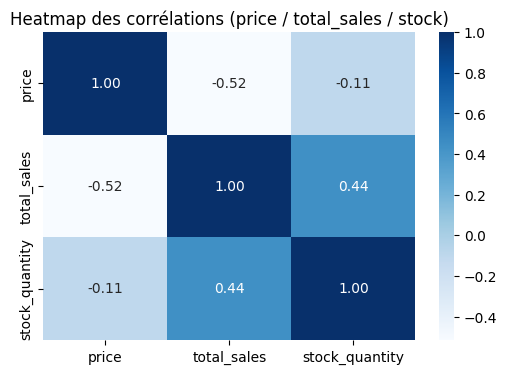

In [ ]:
############################
# Analyse des corrélations #
############################
#Création d'une heatmap de corrélation avec les variables stock, sales et price
cols_corr = ["price", "total_sales", "stock_quantity"]
df_corr = df_merge_web_supp[cols_corr]
corr_matrix = df_corr.corr()
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Heatmap des corrélations (price / total_sales / stock)")
plt.show()

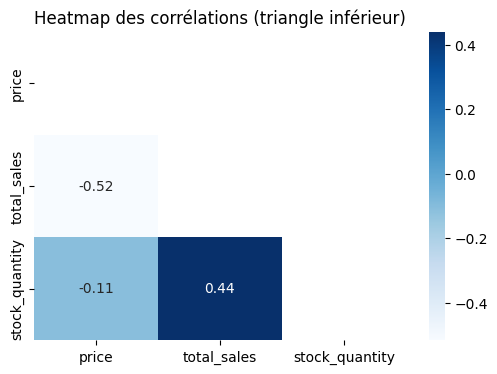

In [ ]:
#On peut également créer un mask pour n'afficher qu'une demi heatmap
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="Blues", fmt=".2f")
plt.title("Heatmap des corrélations (triangle inférieur)")
plt.show()

***Conclusion corrélation :***

**- price vs total_sales : corrélation ≈ -0,52 (négative modérée)**
Plus le prix augmente, plus les quantités vendues ont tendance à diminuer. C’est cohérent : des produits plus chers se vendent généralement moins en volume.

**- total_sales vs stock_quantity : corrélation ≈ +0,44 (positive modérée)**
Les produits qui se vendent le plus sont aussi ceux qui ont tendance à avoir plus de stock disponible. Cela suggère une logique de gestion de stock orientée vers les produits “best-sellers”.

**- price vs stock_quantity : corrélation ≈ -0,11 (négative faible)**
Il n’y a pas de relation forte entre le prix et le stock. Le niveau de stock ne semble pas dépendre directement du prix, ou alors l’effet est très léger.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [ ]:
#Mettre le dataset df_merge sur un fichier Excel
############################################
# Etape 5.6 - Export du dataset final en Excel
############################################

# 1) Choisir le dataset final
df_final = df_merge_web_supp.copy()

# 2) (Optionnel mais conseillé) Vérifications rapides
print("Dimensions df_final (lignes, colonnes) :", df_final.shape)
print("\nValeurs manquantes par colonne :")
print(df_final.isna().sum().sort_values(ascending=False).head(10))

# 3) Export en Excel
nom_fichier = "df_final_merge_web_supp.xlsx"
df_final.to_excel(nom_fichier, index=False)

print(f"\n Fichier Excel créé : {nom_fichier}")
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.


Dimensions df_final (lignes, colonnes) : (714, 15)

Valeurs manquantes par colonne :
product_type      1
onsale_web        0
product_id        0
stock_quantity    0
stock_status      0
purchase_price    0
price             0
id_web            0
sku               0
tax_status        0
dtype: int64

 Fichier Excel créé : df_final_merge_web_supp.xlsx
